---
date: last-modified
---

# TEMPO Programmatic Data Access with Python
## AAPCA Virtual Training — May 20, 2026

**Training for state and local air agency ambient monitoring and modeling personnel**

---

### Overview

This hands-on tutorial demonstrates how to programmatically access and visualize [TEMPO](https://tempo.si.edu/) (Tropospheric Emissions: Monitoring of Pollution) air quality data using Python. You'll work through a complete workflow — from authentication through publication-ready mapping — using a case study of NO₂ concentrations across the **Northeast U.S. corridor**.

**Why programmatic access?** Automate data retrieval for regular monitoring workflows, batch processing, and reproducible analysis — essential capabilities for agencies running recurring air quality assessments.

**Tutorial Navigation:** Variables and text highlighted in <mark>yellow</mark> are key parameters you'll want to modify for your own region, time period, or data requirements.

### Prerequisites

**Required:**
- Free [NASA Earthdata Login account](https://urs.earthdata.nasa.gov/) (create one now if you haven't already)
- Basic Python familiarity (variables, functions, libraries)

**Helpful but not required:**
- Experience with Jupyter notebooks or Google Colab
- Familiarity with geospatial data or NetCDF files

### What You'll Learn

| Section | Topic | ~Time |
|---------|-------|-------|
| 1 | Setup & Authentication | 15 min |
| 2 | Building & Submitting Data Requests | 25 min |
| 3 | Inspecting TEMPO Data Files | 20 min |
| 4 | Quality Control & Visualization | 35 min |
| 5 | Next Steps & Resources | 15 min |

### Data & Scope

- **Product**: <mark>TEMPO_NO2_L3_V04 (Level-3 gridded NO₂ columns)</mark>
- **Resolution**: ~2.1 km × 4.4 km, hourly during daylight
- **Coverage**: North America (Field of Regard)
- **Example region**: <mark>Northeast U.S. corridor (Washington, D.C. to New York City)</mark>
- **Example time**: <mark>July 24, 2025, afternoon (summer weekday)</mark>

*Methods demonstrated apply to other TEMPO products (formaldehyde, ozone, etc.) and any region within the TEMPO Field of Regard.*

### Notebook Author

- **Author:** Daniel Kaufman, Ph.D. — NASA Atmospheric Science Data Center (ASDC)
- **Based on:** [harmony-py examples](https://github.com/nasa/harmony-py/tree/main/examples) and [Harmony documentation](https://harmony.earthdata.nasa.gov/docs)


## 1. Setup

### 1.1 Install Required Packages

These packages may not be pre-installed in Google Colab. This cell installs them quietly.


In [ ]:
!pip install --quiet harmony-py cartopy

### 1.2 Import Libraries

We'll use these libraries throughout the tutorial:
- **harmony-py** — NASA's Python client for the Harmony data services API
- **xarray** — For opening and exploring multi-dimensional scientific data
- **cartopy + matplotlib** — For creating maps with geographic projections


In [ ]:
# Data access
import datetime as dt
import os
from getpass import getpass
from harmony import BBox, Client, Collection, Request

# Data inspection
import xarray as xr

# Visualization
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from xarray.plot.utils import label_from_attrs

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


### 1.3 Authenticate with NASA Earthdata

To access TEMPO data, you need a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account.


Enter your Earthdata Login credentials (username and password) to access TEMPO data. Your credentials are securely passed to NASA's servers and are not stored in this notebook.

In [ ]:
username = input("Earthdata Username:")

harmony_client = Client(auth=(username, getpass()))
print(f"✓ Authenticated as: {username}")

## 2. Downloading TEMPO Data via Harmony

**Estimated time for download:** 2–5 minutes (depends on data size and network speed)

### What is Harmony?

[Harmony](https://harmony.earthdata.nasa.gov/) is NASA's cloud services orchestrator for Earth science data. It provides a unified API for:
- **Subsetting** — Extract just the spatial/temporal slice you need
- **Reformatting** — Convert between data formats
- **Reprojection** — Transform to your desired coordinate system

Instead of downloading large full-scan files, Harmony delivers only the data you request. This is especially valuable for TEMPO, where a single full-scan file can be ~900 MB.

### 2.1 Define Your Data Request

A Harmony request has three key components:

1. **Collection** — Which data product (identified by a Collection Concept ID)
2. **Temporal** — What time period
3. **Spatial** — What geographic area

**Finding Collection IDs:** Search for your product (e.g., "TEMPO_NO2_L3") in [NASA Earthdata Search](https://search.earthdata.nasa.gov/search), select the desired version, and copy the Collection Concept ID from the URL or metadata.

In this example, we will be using [`TEMPO_NO2_L3_V04`](https://search.earthdata.nasa.gov/search/granules/collection-details?p=C3685896708-LARC_CLOUD).


#### Time Selection

TEMPO scans North America hourly during daylight hours. All times are in **UTC**.

For our example, we want an **afternoon observation on July 24, 2025** — a summer weekday when traffic-related NO₂ should be visible in the Northeast corridor.

| Time Zone | Local Time | UTC Equivalent |
|-----------|-----------|----------------|
| Eastern (EDT) | 1:00 PM | 17:00 UTC |
| Central (CDT) | 12:00 PM | 17:00 UTC |
| Mountain (MDT) | 11:00 AM | 17:00 UTC |
| Pacific (PDT) | 10:00 AM | 17:00 UTC |


In [ ]:
# Display what we're requesting
print("Request parameters:")
print("  Date/time: July 24, 2025, 17:00–17:30 UTC (1:00 PM Eastern)")
print("  This is a 30-minute window — enough to capture the start of one TEMPO scan")
print()
print("Note: TEMPO times are in UTC. Common conversions:")
print("  EDT = UTC - 4 hours  |  CDT = UTC - 5 hours")
print("  MDT = UTC - 6 hours  |  PDT = UTC - 7 hours")

Request parameters:
  Date/time: July 24, 2025, 17:00–17:30 UTC (1:00 PM Eastern)
  This is a 30-minute window — enough to capture the start of one TEMPO scan

Note: TEMPO times are in UTC. Common conversions:
  EDT = UTC - 4 hours  |  CDT = UTC - 5 hours
  MDT = UTC - 6 hours  |  PDT = UTC - 7 hours


#### Spatial Selection

Our example covers the <mark>Northeast U.S. corridor from Washington, D.C. to New York City</mark>:
- Longitude: <mark>-77.5° to -73.5° (4° wide)</mark>
- Latitude: <mark>38.5° to 41.0° (2.5° tall)</mark>

This captures major metro areas (D.C., Baltimore, Philadelphia, NYC) and the I-95 corridor — a high-traffic region where state/local agencies actively monitor NO₂.

📍 [View the coverage area on a map](https://geojson.io/next/#data=data:application/json,%7B%22type%22%3A%22FeatureCollection%22%2C%22features%22%3A%5B%7B%22type%22%3A%22Feature%22%2C%22geometry%22%3A%7B%22type%22%3A%22Polygon%22%2C%22coordinates%22%3A%5B%5B%5B-77.5%2C38.5%5D%2C%5B-77.5%2C41.0%5D%2C%5B-73.5%2C41.0%5D%2C%5B-73.5%2C38.5%5D%2C%5B-77.5%2C38.5%5D%5D%5D%7D%2C%22properties%22%3A%7B%22name%22%3A%22NE%20Corridor%22%7D%7D%5D%7D)


In [ ]:
request = Request(
    # Collection Concept ID for TEMPO_NO2_L3_V04
    # (Level-3 gridded NO₂ tropospheric and stratospheric columns)
    collection=Collection(id="C3685896708-LARC_CLOUD"),
    # 30-minute time window (in UTC)
    temporal={
        "start": dt.datetime(2025, 7, 24, 17, 00, 0),
        "stop": dt.datetime(2025, 7, 24, 17, 30, 0),
    },
    # Bounding box: (west, south, east, north)
    spatial=BBox(-77.5, 38.5, -73.5, 41.0),
)

# Validate before submitting
print("Request summary:")
print(f"  ✓ Valid: {request.is_valid()}")
print("  ✓ Collection: TEMPO_NO2_L3_V04")
print(f"  ✓ Time: {request.temporal['start']} to {request.temporal['stop']} UTC")
print(f"  ✓ Spatial: {request.spatial}")
print("  ✓ Region: NE U.S. corridor (DC → NYC)")

Request summary:
  ✓ Valid: True
  ✓ Collection: TEMPO_NO2_L3_V04
  ✓ Time: 2025-07-24 17:00:00 to 2025-07-24 17:30:00 UTC
  ✓ Spatial: BBox: West:-77.5, South:38.5, East:-73.5, North:41.0
  ✓ Region: NE U.S. corridor (DC → NYC)


### 2.2 Submit and Monitor the Request

When you submit a request, Harmony:
1. Finds matching granules in NASA's archive
2. Subsets them to your spatial/temporal bounds
3. Stages the results for download

The job ID lets you track progress.


⏱️ This typically takes about 30 seconds. Good time to stretch or ask questions in chat.

In [ ]:
job_id = harmony_client.submit(request)
print(f"Job submitted! ID: {job_id}")
print("Waiting for processing...")

harmony_client.wait_for_processing(job_id, show_progress=True)
print("\n✓ Processing complete!")

Job submitted! ID: 18616fb3-4c2a-435e-a075-c31e7f930c49
Waiting for processing...


 [ Processing: 100% ] |###################################################| [|]



✓ Processing complete!


### 2.3 Download the Data

Download the processed (subset) files. In Colab, we'll save to a folder in the runtime's filesystem.


In [ ]:
download_dir = "tempo_data"
os.makedirs(download_dir, exist_ok=True)

results = harmony_client.download_all(job_id, directory=download_dir)
all_results_stored = [f.result() for f in results]

print(f"✓ Downloaded {len(all_results_stored)} file(s) to '{download_dir}/'")
for f in all_results_stored:
    size_mb = os.path.getsize(f) / 1e6
    print(f"  • {os.path.basename(f)} ({size_mb:.1f} MB)")

tempo_data/211548767_TEMPO_NO2_L3_V04_20250724T171656Z_S009_subsetted.nc4
✓ Downloaded 1 file(s) to 'tempo_data/'
  • 211548767_TEMPO_NO2_L3_V04_20250724T171656Z_S009_subsetted.nc4 (2.8 MB)


In [ ]:
assert len(all_results_stored) > 0, (
    "No files were downloaded. Check:\n"
    "  • Is the date within TEMPO's operational period (Aug 2023–present)?\n"
    "  • Is the time during daylight hours (UTC)?\n"
    "  • Are the spatial bounds within North America?\n"
    "  • Check the TEMPO Daily Operations Log for outages."
)

### 2.4 Troubleshooting Common Issues

| Problem | Likely Cause | Solution |
|---------|-------------|----------|
| Authentication error | Wrong credentials | Re-check Colab Secrets values |
| No data returned | Time outside TEMPO coverage | TEMPO is operational Aug 2023–present; only daylight hours |
| No data returned | Spatial mismatch | Verify bounds are within North America |
| No data returned | Special or off-nominal operations | Check the [TEMPO Daily Operations Log](https://github.com/Smithsonian/TEMPO-Observations-log/blob/main/daily_log.md) |
| Timeout | Large request | Reduce spatial area or time window |
| Import error | Package not installed | Re-run the `!pip install` cell |


## 3. Inspecting TEMPO Data Files

Now that we have data downloaded, let's explore what's inside a TEMPO Level-3 file.

### 3.1 Open the File

We'll use `xarray.open_datatree()` which preserves TEMPO's hierarchical group structure.


In [ ]:
file_path = all_results_stored[0]
print(f"Opening: {os.path.basename(file_path)}")

datatree = xr.open_datatree(file_path)
datatree

Opening: 211548767_TEMPO_NO2_L3_V04_20250724T171656Z_S009_subsetted.nc4


<xarray.DataTree>
Group: /
│   Dimensions:    (latitude: 125, longitude: 200, time: 1)
│   Coordinates:
│     * latitude   (latitude) float32 500B 38.51 38.53 38.55 ... 40.95 40.97 40.99
│     * longitude  (longitude) float32 800B -77.49 -77.47 -77.45 ... -73.53 -73.51
│     * time       (time) datetime64[ns] 8B 2025-07-24T17:17:14.020128512
│   Data variables:
│       weight     (latitude, longitude) float32 100kB ...
│   Attributes: (12/46)
│       history:                           2026-04-09T13:57:14Z: /proj/sdpc_soft/...
│       scan_num:                          9
│       time_coverage_start:               2025-07-24T17:16:56Z
│       time_coverage_end:                 2025-07-24T18:16:37Z
│       time_coverage_start_since_epoch:   1437412634.0201285
│       time_coverage_end_since_epoch:     1437416215.6435742
│       ...                                ...
│       build_dmrpp_metadata.created:      2026-04-09T14:21:40Z
│       build_dmrpp_metadata.build_dmrpp:  3.21.1-367
│       build_dmrpp_metadata.bes:          3.21.1-367
│       build_dmrpp_metadata.libdap:       libdap-3.21.1-99
│       build_dmrpp_metadata.invocation:   build_dmrpp -f /tmp/tmpilarivvm/TEMPO_...
│       history_json:                      [{"$schema":"https:\/\/harmony.earthda...
├── Group: /product
│       Dimensions:                                  (time: 1, latitude: 125,
│                                                     longitude: 200)
│       Data variables:
│           vertical_column_troposphere              (time, latitude, longitude) float64 200kB ...
│           vertical_column_troposphere_uncertainty  (time, latitude, longitude) float64 200kB ...
│           vertical_column_stratosphere             (time, latitude, longitude) float64 200kB ...
│           main_data_quality_flag                   (time, latitude, longitude) float32 100kB ...
├── Group: /qa_statistics
│       Dimensions:                                              (time: 1,
│                                                                 latitude: 125,
│                                                                 longitude: 200)
│       Data variables:
│           num_vertical_column_total_samples                    (time, latitude, longitude) float64 200kB ...
│           max_vertical_column_troposphere_sample               (time, latitude, longitude) float64 200kB ...
│           min_vertical_column_stratosphere_sample              (time, latitude, longitude) float64 200kB ...
│           num_vertical_column_stratosphere_samples             (time, latitude, longitude) float64 200kB ...
│           num_vertical_column_troposphere_samples              (time, latitude, longitude) float64 200kB ...
│           min_vertical_column_total_sample                     (time, latitude, longitude) float64 200kB ...
│           num_vertical_column_troposphere_uncertainty_samples  (time, latitude, longitude) float64 200kB ...
│           max_vertical_column_troposphere_uncertainty_sample   (time, latitude, longitude) float64 200kB ...
│           min_vertical_column_troposphere_uncertainty_sample   (time, latitude, longitude) float64 200kB ...
│           max_vertical_column_total_sample                     (time, latitude, longitude) float64 200kB ...
│           max_vertical_column_stratosphere_sample              (time, latitude, longitude) float64 200kB ...
│           min_vertical_column_troposphere_sample               (time, latitude, longitude) float64 200kB ...
├── Group: /geolocation
│       Dimensions:                 (time: 1, latitude: 125, longitude: 200)
│       Data variables:
│           solar_zenith_angle      (time, latitude, longitude) float32 100kB ...
│           viewing_zenith_angle    (time, latitude, longitude) float32 100kB ...
│           relative_azimuth_angle  (time, latitude, longitude) float32 100kB ...
└── Group: /support_data
        Dimensions:                            (time: 1, latitude: 125, longitude: 200)
        Data variables: (12/16

### 3.2 Understanding TEMPO File Structure

TEMPO Level-3 files are organized into **groups**:

| Group | Contains |
|-------|----------|
| `/` (root) | Global attributes, grid weight, lat/lon/time coordinates |
| `product/` | Science data variables (NO₂ columns, quality flags) |
| `geolocation/` | Solar/viewing geometry (zenith angles, azimuth) |
| `support_data/` | Ancillary data (surface pressure, terrain, AMFs) |
| `qa_statistics/` | Per-pixel aggregation statistics |

The latitude and longitude are **coordinate dimensions** shared across all groups (not separate variables in a geolocation group, as in Level-2 files).

Let's explore the groups and their variables:


In [ ]:
# List all groups and their variables
print("TEMPO L3 file structure:")
print("=" * 50)
for node in datatree.subtree:
    path = node.path or "/ (root)"
    if node.ds is not None:
        vars_list = list(node.ds.data_vars)
        coords_list = list(node.ds.coords)
        if vars_list or coords_list:
            print(f"\n📁 {path}")
            if coords_list:
                print(f"   Coordinates: {coords_list}")
            for var in vars_list[:6]:
                print(f"   • {var}")
            if len(vars_list) > 6:
                print(f"   ... and {len(vars_list) - 6} more")

TEMPO L3 file structure:

📁 /
   Coordinates: ['longitude', 'latitude', 'time']
   • weight

📁 /product
   Coordinates: ['longitude', 'latitude', 'time']
   • vertical_column_troposphere
   • vertical_column_troposphere_uncertainty
   • vertical_column_stratosphere
   • main_data_quality_flag

📁 /qa_statistics
   Coordinates: ['longitude', 'latitude', 'time']
   • num_vertical_column_total_samples
   • max_vertical_column_troposphere_sample
   • min_vertical_column_stratosphere_sample
   • num_vertical_column_stratosphere_samples
   • num_vertical_column_troposphere_samples
   • min_vertical_column_total_sample
   ... and 6 more

📁 /geolocation
   Coordinates: ['longitude', 'latitude', 'time']
   • solar_zenith_angle
   • viewing_zenith_angle
   • relative_azimuth_angle

📁 /support_data
   Coordinates: ['longitude', 'latitude', 'time']
   • surface_pressure
   • amf_cloud_pressure
   • vertical_column_total_uncertainty
   • vertical_column_total
   • terrain_height
   • fitted_slant_co

### 3.3 Examine a Data Variable

Let's look at the **tropospheric NO₂ column** — this is the most relevant variable for surface air quality monitoring, as it represents NO₂ in the lower atmosphere where pollution sources are located.


In [ ]:
data_array = datatree["product/vertical_column_troposphere"]

print("Variable: vertical_column_troposphere")
print(f"  Shape: {data_array.shape}")
print(f"  Dimensions: {data_array.dims}")
print(f"  Units: {data_array.attrs.get('units', 'not specified')}")
print(f"  Long name: {data_array.attrs.get('long_name', 'not specified')}")
print(f"  Fill value: {data_array.attrs.get('_FillValue', 'not specified')}")

data_array

Variable: vertical_column_troposphere
  Shape: (1, 125, 200)
  Dimensions: ('time', 'latitude', 'longitude')
  Units: molecules/cm^2
  Long name: troposphere nitrogen dioxide vertical column
  Fill value: not specified


<xarray.DataArray 'vertical_column_troposphere' (time: 1, latitude: 125,
                                                 longitude: 200)> Size: 200kB
[25000 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-07-24T17:17:14.020128512
  * latitude   (latitude) float32 500B 38.51 38.53 38.55 ... 40.95 40.97 40.99
  * longitude  (longitude) float32 800B -77.49 -77.47 -77.45 ... -73.53 -73.51
Attributes:
    long_name:  troposphere nitrogen dioxide vertical column
    units:      molecules/cm^2

## 4. Quality Control and Visualization

### 4.1 Understanding TEMPO Quality Flags

TEMPO data should be filtered to remove low-confidence measurements before analysis. We apply three filters:

| Filter | Variable | Threshold | Rationale |
|--------|----------|-----------|-----------|
| Quality flag | `product/main_data_quality_flag` | Remove where > 1 | Excludes pixels flagged as "bad" (flag = 2) |
| Cloud fraction | `support_data/eff_cloud_fraction` | Remove where > 0.5 | Clouds obscure the tropospheric column below them |
| Solar zenith angle | `geolocation/solar_zenith_angle` | Remove where > 80° | Retrievals degrade at high solar zenith angles (near sunrise/sunset) |

**Note:** We retain both "normal" (flag = 0) and "suspect" (flag = 1) pixels here. The cloud fraction and solar zenith angle filters provide additional screening that compensates for including suspect-flagged data — giving better spatial coverage while maintaining reliability.


In [ ]:
# Load the three filter variables
quality_flags = datatree["product/main_data_quality_flag"]
cloud_fraction = datatree["support_data/eff_cloud_fraction"]
solar_zenith = datatree["geolocation/solar_zenith_angle"]

print("Filter variable summary:")
print("\n  main_data_quality_flag:")
print(f"    Flag 0 (normal):  {int((quality_flags == 0).sum())} pixels")
print(f"    Flag 1 (suspect): {int((quality_flags == 1).sum())} pixels")
print(f"    Flag 2 (bad):     {int((quality_flags == 2).sum())} pixels")

print("\n  eff_cloud_fraction:")
print(f"    Range: {float(cloud_fraction.min()):.2f} – {float(cloud_fraction.max()):.2f}")
print(f"    Pixels with cloud fraction > 0.5: {int((cloud_fraction > 0.5).sum())}")

print("\n  solar_zenith_angle:")
print(f"    Range: {float(solar_zenith.min()):.1f}° – {float(solar_zenith.max()):.1f}°")
print(f"    Pixels with SZA > 80°: {int((solar_zenith > 80).sum())}")

Filter variable summary:

  main_data_quality_flag:
    Flag 0 (normal):  25000 pixels
    Flag 1 (suspect): 0 pixels
    Flag 2 (bad):     0 pixels

  eff_cloud_fraction:
    Range: 0.00 – 0.69
    Pixels with cloud fraction > 0.5: 209

  solar_zenith_angle:
    Range: 19.2° – 22.2°
    Pixels with SZA > 80°: 0


### 4.2 Apply Quality Filtering

We'll build a combined mask that keeps only pixels passing **all three** criteria, then apply it to the NO₂ data.


In [ ]:
# Build combined quality mask: True = keep, False = remove
mask = (
    (quality_flags <= 1)  # Keep normal + suspect (remove bad)
    & (cloud_fraction <= 0.5)  # Keep relatively clear pixels
    & (solar_zenith <= 80)  # Keep reasonable sun angles
)

# Apply mask to NO₂ data
good_data = data_array.where(mask).squeeze()

# Report filtering results
total_pixels = int(data_array.size)
kept_pixels = int(mask.sum())
removed_pixels = total_pixels - kept_pixels

print("Filtering results:")
print(f"  Total pixels:    {total_pixels:,}")
print(f"  Kept:            {kept_pixels:,} ({100 * kept_pixels / total_pixels:.1f}%)")
print(f"  Removed:         {removed_pixels:,} ({100 * removed_pixels / total_pixels:.1f}%)")
print(f"\nFiltered data shape: {good_data.shape}")
print(f"Data size in memory: {good_data.nbytes / 1e6:.1f} MB")
print(
    f"\nData range: {float(good_data.min()):.2e} to {float(good_data.max()):.2e} {data_array.attrs.get('units', '')}"
)
print(f"Mean value: {float(good_data.mean()):.2e}")
print()
print("For reference (tropospheric NO₂ columns):")
print("  • Urban/polluted areas:  > 5×10¹⁵ molecules/cm²")
print("  • Suburban/moderate:     1–5×10¹⁵ molecules/cm²")
print("  • Rural/clean:           < 1×10¹⁵ molecules/cm²")

Filtering results:
  Total pixels:    25,000
  Kept:            24,791 (99.2%)
  Removed:         209 (0.8%)

Filtered data shape: (125, 200)
Data size in memory: 0.2 MB

Data range: -3.05e+15 to 1.74e+16 molecules/cm^2
Mean value: 2.27e+15

For reference (tropospheric NO₂ columns):
  • Urban/polluted areas:  > 5×10¹⁵ molecules/cm²
  • Suburban/moderate:     1–5×10¹⁵ molecules/cm²
  • Rural/clean:           < 1×10¹⁵ molecules/cm²


### 4.3 Create a Map

Now let's create a publication-ready map showing NO₂ concentrations across our study area. We'll add geographic context (state boundaries, roads) to help interpret the spatial patterns.


In [ ]:
# Set up the map projection and features
data_proj = ccrs.PlateCarree()

# Add major roads for context (helps identify traffic corridors)
roads = cfeature.NaturalEarthFeature(
    category="cultural",
    name="roads",
    scale="10m",
    facecolor="none",
)

In [ ]:
def make_nice_map(axis):
    """Configure map extent and add geographic features."""
    # Set extent slightly larger than our data region for context
    axis.set_extent([-78.5, -72.5, 38.0, 41.5], crs=data_proj)

    # Add geographic features
    axis.add_feature(cfeature.OCEAN, color="lightblue", zorder=0)
    axis.add_feature(cfeature.LAND, color="#f0f0f0", zorder=0)
    axis.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.8)
    axis.add_feature(roads, edgecolor="white", linewidth=0.5)

    # Add gridlines with labels
    grid = axis.gridlines(draw_labels=["left", "bottom"], dms=True, linestyle=":")
    grid.xformatter = LONGITUDE_FORMATTER
    grid.yformatter = LATITUDE_FORMATTER

    return axis

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_roads.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


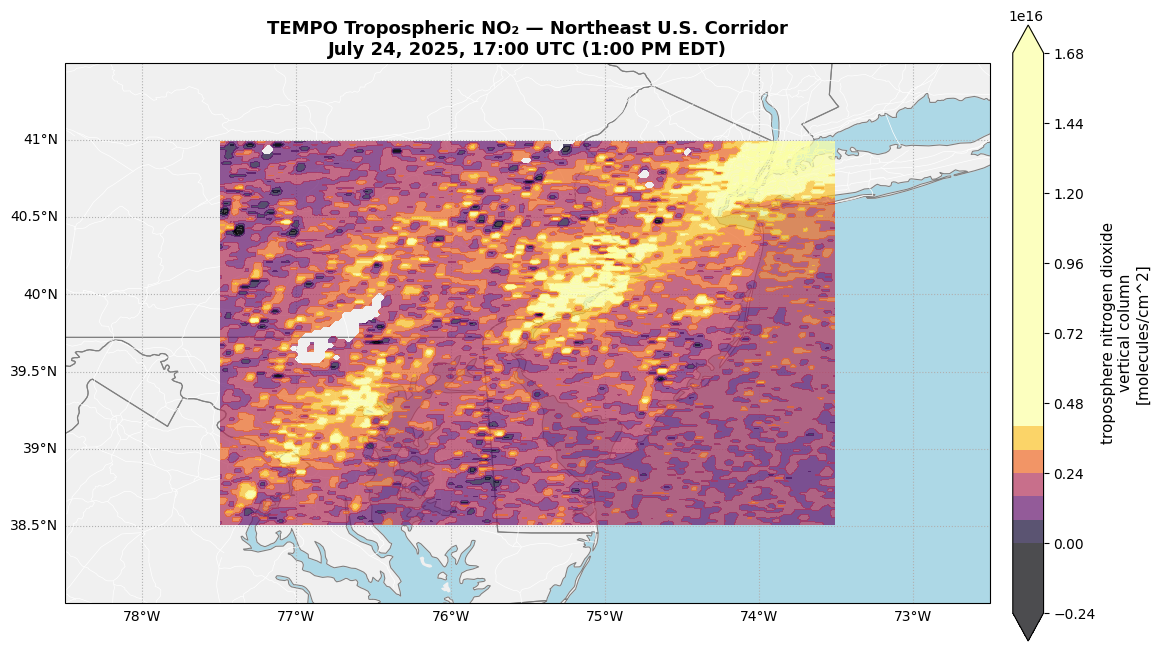


✓ Map created successfully!


In [ ]:
# Create the figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": data_proj})

make_nice_map(ax)

# Plot NO₂ data using coordinate arrays
# For L3 gridded data, lat/lon are 1D coordinate dimensions
contour_handle = ax.contourf(
    good_data.coords["longitude"],
    good_data.coords["latitude"],
    good_data.values,
    levels=30,
    vmin=0,
    vmax=float(good_data.quantile(0.95)),  # Cap at 95th percentile for better color contrast
    extend="both",
    alpha=0.7,
    cmap="inferno",
    transform=data_proj,
    zorder=2,
)

# Add colorbar
cb = plt.colorbar(contour_handle, ax=ax, shrink=0.8, pad=0.02)
cb.set_label(label_from_attrs(data_array), fontsize=11)

# Add title
ax.set_title(
    "TEMPO Tropospheric NO₂ — Northeast U.S. Corridor\nJuly 24, 2025, 17:00 UTC (1:00 PM EDT)",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

print("\n✓ Map created successfully!")

### 4.4 Interpreting the Map

**What to look for:**
- **Urban hotspots** — Higher NO₂ over cities (NYC, Philadelphia, Baltimore, D.C.)
- **Highway corridors** — Elevated NO₂ along the I-95 corridor
- **Rural areas** — Lower background NO₂ away from emission sources
- **Missing data** — White areas may indicate cloud cover (clouds block TEMPO's view)

**Comparison to ground monitors:**
TEMPO tropospheric columns (molecules/cm²) are not directly comparable to surface-level concentrations (ppb) from ground monitors — they represent the *total column* of NO₂ through the troposphere. However, spatial patterns should correlate with ground monitoring networks, and column-to-surface relationships can be established for your area.


## 5. Next Steps and Resources

### What You Accomplished

- ✅ Authenticated with NASA Earthdata via Google Colab
- ✅ Built and submitted a targeted data request using Harmony
- ✅ Downloaded subset TEMPO NO₂ data for a specific region and time
- ✅ Explored TEMPO file structure and variables with xarray
- ✅ Applied quality filtering using TEMPO's data quality flags
- ✅ Created a publication-ready map of air quality data

### Adapting This Workflow for Your Agency

To use this workflow for your own monitoring area:

1. **Change the spatial bounds** — Replace the `BBox()` coordinates with your state/region
2. **Change the time** — Select dates relevant to your monitoring needs (remember UTC!)
3. **Change the product** — Swap the Collection ID for formaldehyde, ozone, etc.
4. **Automate** — Wrap this workflow in a script that runs on a schedule

### Other TEMPO Products Available

| Product | Collection ID (V03 L3) | Relevance |
|---------|----------------------|-----------|
| NO₂ (this tutorial) | C3685896708-LARC_CLOUD | Traffic, industrial emissions |
| Formaldehyde (HCHO) | C3685897141-LARC_CLOUD | Biogenic VOCs, industrial sources |
| Total Ozone (O₃) | C3685896625-LARC_CLOUD | Photochemical smog, health impacts |
| Ozone (O₃) Profile | C3685896402-LARC_CLOUD | Photochemical smog, health impacts |

### Alternative Data Access Methods

| Method | Best For | Notes |
|--------|----------|-------|
| **Harmony** (this tutorial) | Subsetting, automation, specific regions | Cloud-optimized, returns only what you need |
| **earthaccess** | Quick exploration, cloud-native workflows | Simpler API, good for browsing |
| **Earthdata Search** | One-time downloads, browsing | Browser-based, visual interface |
| **Direct S3 access** | Large-scale processing in AWS | Fastest for cloud-based analysis |

### Potential Extensions

- **Time series analysis** — Download multiple scans across a day to see diurnal patterns
- **Multi-day composites** — Average across cloud-free periods for cleaner spatial patterns
- **Ground truth comparison** — Overlay EPA AQS monitor locations on TEMPO maps
- **Multi-pollutant** — Compare NO₂ and formaldehyde to assess VOC-NOₓ sensitivity
- **Event monitoring** — Track wildfire plumes, industrial incidents, or exceptional events

### Resources

- **TEMPO Mission:** https://tempo.si.edu/
- **ASDC TEMPO Landing Page:** https://asdc.larc.nasa.gov/project/TEMPO
- **Earthdata Search:** https://search.earthdata.nasa.gov/search?q=TEMPO
- **Earthdata Forum (questions):** https://forum.earthdata.nasa.gov/
- **harmony-py Documentation:** https://harmony-py.readthedocs.io/
- **ASDC Data Tutorials:** https://nasa.github.io/ASDC_Data_and_User_Services/

### Questions?

**Contact:** Daniel Kaufman — daniel.kaufman@nasa.gov

Thank you for participating! 🛰️
